# How does FinRobot respond to a sudden +200bps rate shock?

**FinRobot** is the financial AI agent. **Tradefloor** is the controlled
environment that measures what the agent does when the world changes.

A historical dataset gives you one realized history. There is no second 2022
in which rates held still, so you cannot ask it what this agent would have
done otherwise.

This notebook creates two worlds that share the same history up to a
checkpoint, changes one variable in one of them, and compares what the same
FinRobot agent does next.

This is an **agent-evaluation** experiment. One seed cannot say which arm was
the better investor. It can say exactly what the same agent, holding the same
book, did differently when one number changed.

## 1. The experiment

```
                    SAME HISTORY
                         |
                      FinRobot
                         |
                    CHECKPOINT
                         |
                +--------+--------+
                |                 |
             CONTROL          +200BPS
                |                 |
             FinRobot          FinRobot
                |                 |
                +--------+--------+
                         |
                      COMPARE
```

Everything before the checkpoint is shared, and byte-identical rather than
merely similar: the same prices, the same order book, the same generator
position, the same portfolio, the same agent. So everything differing
afterwards descends from the one field that changed.

### Live calls and replay

Tradefloor's market is deterministic and FinRobot is an LLM behind an API, so
two live runs give two different agents. This notebook calls FinRobot when a
key is present in the environment and replays a recorded run when one is not.
The market re-executes for real in both cases; only the agent's answers come
from the recording, keyed by the exact text it was sent.

A live run needs `pip install "tradefloor[finrobot]"`, Python 3.11, and it
spends money per decision. The key is read from the environment at the point
of the call and is never written into this notebook.

In [1]:
import json
import sys
from pathlib import Path

import tradefloor as tf
from tradefloor.counterfactual import World, agree, compare

# The production adapter. This notebook implements none of the integration.
# `tradefloor/integrations/finrobot.py` is the source of truth, and this is
# the same object the shipped example and the test suite use.
from tradefloor.integrations.finrobot import (MANDATE, MANDATE_VERSION,
                                              FinRobotAdapter, Transcript)

# The experiment's constants come from the example script for the same
# reason. One definition, so the notebook and the script cannot drift into
# describing two different experiments.
sys.path.insert(0, str(Path.cwd()))
import rate_shock as experiment

# Live when this machine can actually do it: a key AND FinRobot installed.
# Either half missing takes the replay path, so the notebook runs anywhere.
# The key is read where the call is made and never lands in this notebook.
LIVE = experiment.can_run_live()

print(f"tradefloor {tf.__version__}")
if LIVE:
    print("mode        live, calling FinRobot")
else:
    missing = ("an API key in " + experiment.LIVE_KEY_VAR
               if not experiment.have_live_key()
               else 'FinRobot: pip install "tradefloor[finrobot]" on Python 3.11')
    print("mode        replay")
    print(f"            live would need {missing}")

tradefloor 0.8.0
mode        replay
            live would need an API key in ANTHROPIC_API_KEY


## 2. The market

Four companies, written down rather than drawn, so the roster is pinned exactly
and the story is legible. They differ in the one property that decides rate
sensitivity in this model: **revenue growth is the duration term**, because a
valuation here is
`1 - (discount - neutral) * 1.5 * (1 + growth * 2)`.

Longest duration first, which is the order every table below uses.

In [2]:
roster = list(experiment.universe())

print(f"{'seed':<24}{experiment.SEED}")
print(f"{'shared history':<24}{experiment.WARMUP_DAYS} days "
      f"({experiment.WARMUP_DAYS * experiment.STEPS_PER_DAY} steps)")
print(f"{'each arm afterwards':<24}{experiment.BRANCH_DAYS} days")
print(f"{'policy rate':<24}{experiment.POLICY_RATE:.2%}")
print(f"{'corporate bond yield':<24}{experiment.DISCOUNT_RATE:.2%}")
print(f"{'starting cash':<24}${experiment.CASH:,.0f}")
print(f"{'FinRobot decides':<24}every {experiment.DECISION_EVERY} steps "
      f"(once a day)")
print()
print(f"  {'':<6}{'what it is':<28}{'growth':>8}{'price':>10}{'ADV':>12}")
for row in experiment.BY_DURATION:
    print(f"  {row[0]:<6}{row[2]:<28}{row[7]:>8.0%}{row[3]:>10,.2f}"
          f"{row[8]:>12,.0f}")

seed                    4242
shared history          20 days (120 steps)
each arm afterwards     20 days
policy rate             4.00%
corporate bond yield    5.50%
starting cash           $50,000,000
FinRobot decides        every 6 steps (once a day)

        what it is                    growth     price         ADV
  NOVA  long-duration growth             35%    112.00   6,000,000
  HELX  mid-duration growth              18%     88.00   4,500,000
  BRDG  short-duration cyclical           6%     70.00   5,000,000
  STAP  minimal-duration defensive        1%     51.00   4,000,000


## 3. Attaching real FinRobot

The adapter wraps
[`finrobot.agents.workflow.SingleAssistant`](https://github.com/AI4Finance-Foundation/FinRobot)
-- FinRobot's supported single-agent entry point, which assembles a
`FinRobot(AssistantAgent)` opposite an `autogen.UserProxyAgent`. Two arguments
matter: no toolkits (FinRobot's library roles carry ones that fetch *real*
market data, describing a different world from this one) and no code
execution.

### Who owns what

| FinRobot owns | Tradefloor owns |
|---|---|
| interpretation | the market and the macro path |
| the portfolio decision | execution, the book, fills, accounting |
| a one-line rationale | checkpoints, forks, interventions, comparison |

FinRobot never touches engine state. It returns JSON; the adapter validates
every action against the listed universe and the supported sides, refuses
anything it cannot execute, and hands share deltas to the same execution path
every other agent uses.

### What it is never shown

`Observation` carries `.engine`, and the engine knows the answer key: fair
value, the nine-way factor attribution of every price move, each company's
mispricing, and the macro path the run has not reached yet. The adapter's
observation mapping is an **allowlist, written out field by field**.
`tests/test_finrobot.py` proves the boundary twice -- once against an engine
that raises if the forbidden surface is touched, once by computing the hidden
values and scanning the text FinRobot receives for them.

The agent is also never told which arm it is in.

In [3]:
if LIVE:
    agent = FinRobotAdapter(
        mode="live",
        llm_config=experiment.llm_config(),
        recorder=Transcript(),
        fundamentals=experiment.FUNDAMENTALS,
        objective=experiment.OBJECTIVE,
        every=experiment.DECISION_EVERY,
        arm="shared",
    )
else:
    transcript = Transcript.load(experiment.FIXTURE)
    agent = FinRobotAdapter(
        mode="replay",
        transcript=transcript,
        fundamentals=experiment.FUNDAMENTALS,
        objective=experiment.OBJECTIVE,
        every=experiment.DECISION_EVERY,
        arm="shared",
    )
    print(f"replaying {len(transcript)} recorded interactions from")
    print(f"  {experiment.FIXTURE.name}")
    for field in ("framework", "framework_version", "entry_point",
                  "provider", "model", "temperature", "mandate_version"):
        print(f"  {field:<20} {transcript.meta.get(field)}")

agent

replaying 60 recorded interactions from
  rate-shock.json
  framework            FinRobot
  framework_version    0.1.5
  entry_point          finrobot.agents.workflow.SingleAssistant
  provider             anthropic
  model                claude-sonnet-4-5-20250929
  temperature          0.0
  mandate_version      1


FinRobotAdapter(mode='replay', arm='shared', every=6, decisions=0)

The mandate is the same in both arms. It says what the agent is for and the
shape of the answer, and says nothing about what is coming. The question the
experiment asks is whether it infers a changed world from the observation.

In [4]:
print(MANDATE)

You manage a portfolio inside a simulated financial market.

Use only the macro, market, portfolio and execution information supplied in the message. You have no other data source, no browsing and no tools. The tickers are synthetic and are not real listed companies, so anything you know about real securities does not apply here.

Seek attractive risk-adjusted returns while controlling downside risk. You may buy, sell, resize or maintain positions. You are not required to trade: if the right decision is to leave the book where it is, say so.

Answer with a single JSON object and nothing else. No preamble, no commentary after it, no code fences.

{
  "actions": [
    {"symbol": "<one of the listed symbols>", "side": "BUY", "quantity": 1234}
  ],
  "rationale": "<one or two sentences>"
}

Rules for the answer:
  - "side" is "BUY", "SELL" or "HOLD".
  - "quantity" is a NUMBER OF SHARES, positive, and is omitted or 0 for HOLD.
  - Sell quantities are positive: the side says the direction.


## 4. Shared history

Twenty days with FinRobot managing the book. The market advances six steps a
day; FinRobot decides once a day.

In [5]:
world = World(seed=experiment.SEED, universe=roster, agent=agent,
              pins=experiment.BASE_PINS, cash=experiment.CASH,
              steps_per_day=experiment.STEPS_PER_DAY,
              ticks_per_step=experiment.TICKS_PER_STEP, label="shared")

world.run(days=experiment.WARMUP_DAYS)

macro = world.engine.macro_state
print(f"day {world.day}, step {world.step}, "
      f"{len(agent.record)} FinRobot decisions")
print()
print(f"{'portfolio value':<22}${world.net_worth():,.0f}")
print(f"{'cash':<22}${world.portfolio.cash:,.0f}")
print(f"{'gross exposure':<22}{world.portfolio.leverage(world.engine):.2f}x")
print(f"{'policy rate':<22}{macro.federal_funds_rate:.2%}")
print(f"{'corporate bond yield':<22}{macro.corporate_bond_yield:.2%}")
print(f"{'VIX':<22}{macro.vix:.1f}")
print()
prices = dict(zip(world.engine.tickers, world.trace[-1]["prices"]))
print(f"  {'':<6}{'shares':>12}{'price':>10}{'value':>16}{'weight':>10}")
for row in experiment.BY_DURATION:
    held = world.trace[-1]["positions"].get(row[0], 0.0)
    value = held * prices[row[0]]
    print(f"  {row[0]:<6}{held:>12,.0f}{prices[row[0]]:>10,.2f}"
          f"{value:>16,.0f}{value / world.net_worth():>10.1%}")

day 20, step 120, 20 FinRobot decisions

portfolio value       $51,600,323
cash                  $8,589,530
gross exposure        0.83x
policy rate           4.00%
corporate bond yield  5.50%
VIX                   23.5

              shares     price           value    weight
  NOVA        25,000    122.10       3,052,500      5.9%
  HELX       181,000     93.16      16,861,960     32.7%
  BRDG       200,819     72.03      14,464,993     28.0%
  STAP       157,823     54.69       8,631,340     16.7%


## 5. The checkpoint

The world's history as data: a few kilobytes of JSON somebody else can resume
without this process, this notebook or this kernel.

In [6]:
mark = world.checkpoint("before the shock")

print(f"{'checkpoint at step':<24}{world.step} (day {world.day})")
print(f"{'policy rate':<24}{experiment.POLICY_RATE:.2%}")
print(f"{'portfolio value':<24}${world.net_worth():,.0f}")
print(f"{'market digest':<24}{world.digest()[:32]}...")
print(f"{'universe fingerprint':<24}{world.universe_fingerprint[:32]}...")
print(f"{'operations in the log':<24}{len(mark.log):,}")

checkpoint at step      120 (day 20)
policy rate             4.00%
portfolio value         $51,600,323
market digest           7018cb628ef546913a4ed013a89bfb54...
universe fingerprint    7a6a37d3584521739a809bfa6bdc32e3...
operations in the log   180


## 6. Fork

Two independent continuations: separate engines, separate portfolios, separate
agents. Driving one cannot perturb the other.

`agree()` is the proof. It runs **before** the intervention and gets reported
rather than assumed, because "identical" is a claim a reader should not have
to take on trust.

In [7]:
control, shock = world.fork("control", "+200bps")
control.agent.arm, shock.agent.arm = "control", "+200bps"

agreement = agree(control, shock)
print(agreement.render())
print()
print(f"control == intervention before the shock: "
      f"{'PASS' if agreement.identical else 'FAIL ' + str(agreement.differences)}")

  market columns         identical  18 columns x 4
  prices                 identical  122.10  93.16  72.03  54.69
  order book             identical  80 levels
  generator state        identical  30 words
  macro chain            identical  federal_funds_rate=0.04  corporate_bond_yield=0.055
  whole engine state     identical  37 fields, day 20
  portfolio              identical  $8,589,530 cash, 4 positions
  agent state            identical  6 fields
  shared history         identical  120 steps

control == intervention before the shock: PASS


## 7. One intervention

```
CONTROL              RATE SHOCK

  4.0%                  6.0%

                          ^
                       +200bps
```

A parallel 200bp shift across both fields, because of how this model
transmits. `federal_funds_rate` reaches a valuation only by steering the
corporate bond yield, which is recomputed at central-bank meetings, the first
scheduled past the end of this run. Moving the policy rate alone would move
the agent and leave the market where it was.

Nothing else differs. Not the model, not the prompt, not the mandate, not the
configuration, not the history, not the portfolio, not the universe, not the
seed, not the execution settings.

In [8]:
shock.intervene(federal_funds_rate=experiment.SHOCKED_POLICY_RATE,
                corporate_bond_yield=experiment.SHOCKED_DISCOUNT_RATE)

print(f"  {'':<24}{'CONTROL':>14}{'RATE SHOCK':>14}")
print("  " + "-" * 52)
print(f"  {'policy rate':<24}{experiment.POLICY_RATE:>13.2%}"
      f"{experiment.SHOCKED_POLICY_RATE:>14.2%}")
print(f"  {'corporate bond yield':<24}{experiment.DISCOUNT_RATE:>13.2%}"
      f"{experiment.SHOCKED_DISCOUNT_RATE:>14.2%}")
print()
print(f"  intervention recorded at step {shock.interventions[0]['step']} "
      f"(day {shock.interventions[0]['day']})")

                                 CONTROL    RATE SHOCK
  ----------------------------------------------------
  policy rate                     4.00%         6.00%
  corporate bond yield            5.50%         7.50%

  intervention recorded at step 120 (day 20)


## 8. Both worlds continue

Twenty more days each, same agent, same mandate, same cadence.

In [9]:
control.run(days=experiment.BRANCH_DAYS)
shock.run(days=experiment.BRANCH_DAYS)

report = compare(control, shock, agreement=agreement)
print(f"control  {control.day} days, {len(control.agent.record)} decisions, "
      f"${control.net_worth():,.0f}")
print(f"shock    {shock.day} days, {len(shock.agent.record)} decisions, "
      f"${shock.net_worth():,.0f}")

control  40 days, 40 decisions, $50,398,424
shock    40 days, 40 decisions, $49,395,869


## 9. The first divergence

The answers below arrive in causal order: the macro changed, the agent's
target changed, its orders changed, the market it traded changed, the
portfolio followed.

They can land on different steps, and the gap between them is informative
when they do. A policy can change its target and send no order that step, so
"decided differently" and "traded differently" are separate questions. In
this run they are two days apart. The agent's answer differs at the first
decision after the fork, but only in its rationale: the orders are the same
in both arms. The first different order comes at step 132, on day 22.

In [10]:
print(report.divergence.render())
print(f"  {'first different ACTION':<26} "
      f"{experiment._where(experiment._action_divergence(control, shock))}")

  intervention applied       step 120   (day 20)
  macro state differs        step 120   (day 20)
  agent decision differs     step 120   (day 20)
  first different order      step 132   (day 22)
  prices differ              step 120   (day 20)
  portfolio paths differ     step 120   (day 20)
  first different ACTION     step 132   (day 22)


One agent, one book, two worlds that were byte-identical a moment earlier,
and what it said in each.

In [11]:
print(experiment._divergence_story(control, shock))

  At step 120 (day 20), the first decision after the fork:

  CONTROL  (policy rate 4.00%)

    SELL 50,000 HELX
    BUY 80,000 STAP
    BUY 30,000 NOVA

    "Reducing overweight HELX position (33% of portfolio) which shows weakness with negative momentum, while adding to outperforming STAP with lowest volatility and beta for downside protection, and increasing NOVA exposure given strong fundamentals (high revenue growth, reasonable valuation) despite recent pullback."

  RATE SHOCK  (policy rate 6.00%)

    SELL 50,000 HELX
    BUY 80,000 STAP
    BUY 30,000 NOVA

    "Rotating from underperforming HELX (-1.98% 5-day) into momentum leader STAP (+3.21% 5-day, lowest beta) and adding to NOVA given strong fundamentals (35% revenue growth, attractive P/E) while VIX remains elevated at 23.5, favoring defensive positioning with lower-beta assets."


## 10. What changed

Behaviour first, then execution, then P&L, in that order on purpose. The
question is what the agent DID, and one seed cannot say which arm made more
money.

In [12]:
# A DataFrame when pandas is around, an aligned block when it is not. The
# library has no dataframe dependency and this notebook does not add one.
def table(rows, columns):
    try:
        import pandas as pd
    except ImportError:
        widths = [max(len(str(r[i])) for r in [columns] + rows)
                  for i in range(len(columns))]
        for row in [columns, ["-" * w for w in widths]] + rows:
            print("  ".join(str(c).ljust(w) if i == 0 else str(c).rjust(w)
                            for i, (c, w) in enumerate(zip(row, widths))))
        return None
    return pd.DataFrame(rows, columns=columns).set_index(columns[0])


rows = []
for label, key, fmt in report.ROWS:
    if key is None:
        continue
    rows.append([label,
                 fmt.format(report.control[key]),
                 fmt.format(report.treatment[key])])

table(rows, ["metric", "control", "rate shock"])

,control,rate shock
metric,,
final gross exposure,0.98x,0.87x
steps it traded on,20,20
orders sent,46,46
unusable responses,0,0
turnover,"$201,930,180","$171,045,137"
trades filled,46,46
partial fills,0,2
refused trades,0,0
cost against arrival,"$84,459","$82,337"


`Comparison` reports the portfolio in aggregate. This experiment is about
**which names** the agent moved, in duration order.

Read the two tables against each other rather than either alone. At the first
decision after the fork the agent sent the same orders in both arms, and its
shocked-arm rationale does not mention rates. Twenty days later the shocked
arm holds far more of the minimal-duration name, `STAP` (23.2% against
8.0%), and less of each of the other three by about the same amount. That is
the direction the model's own valuation moved for `STAP`, but the cuts are not
ordered by duration: the mid-duration name fell furthest.

One seed cannot say which of those is the agent and which is the path the
market took it down. An earlier recording of this experiment, on an earlier
version of the market, ended holding more of the long-duration name in the
shocked arm, so the two recordings disagree too.

In [13]:
left = experiment._weights(control)
right = experiment._weights(shock)
rows = [[experiment._label(row),
         f"{left.get(row[0], 0.0):.1%}",
         f"{right.get(row[0], 0.0):.1%}",
         f"{right.get(row[0], 0.0) - left.get(row[0], 0.0):+.1%}"]
        for row in experiment.BY_DURATION]

a_sides, b_sides = experiment._sides(control), experiment._sides(shock)
rows.append(["", "", "", ""])
for side in ("BUY", "SELL", "HOLD"):
    rows.append([f"{side} instructions after the fork",
                 str(a_sides[side]), str(b_sides[side]), ""])

table(rows, ["final weight", "control", "rate shock", "delta"])

,control,rate shock,delta
final weight,,,
NOVA (long-duration),14.0%,5.6%,-8.4%
HELX (mid-duration),37.0%,27.3%,-9.7%
BRDG (short-duration),38.7%,30.6%,-8.1%
STAP (minimal-duration),8.0%,23.2%,+15.2%
,,,
BUY instructions after the fork,22,22,
SELL instructions after the fork,24,24,
HOLD instructions after the fork,0,0,


## 11. Two pictures

### Portfolio value and gross exposure

The grey line is the shared history, drawn once because only one of it
exists. The dashed line is the fork. The two arms exist only to its right.

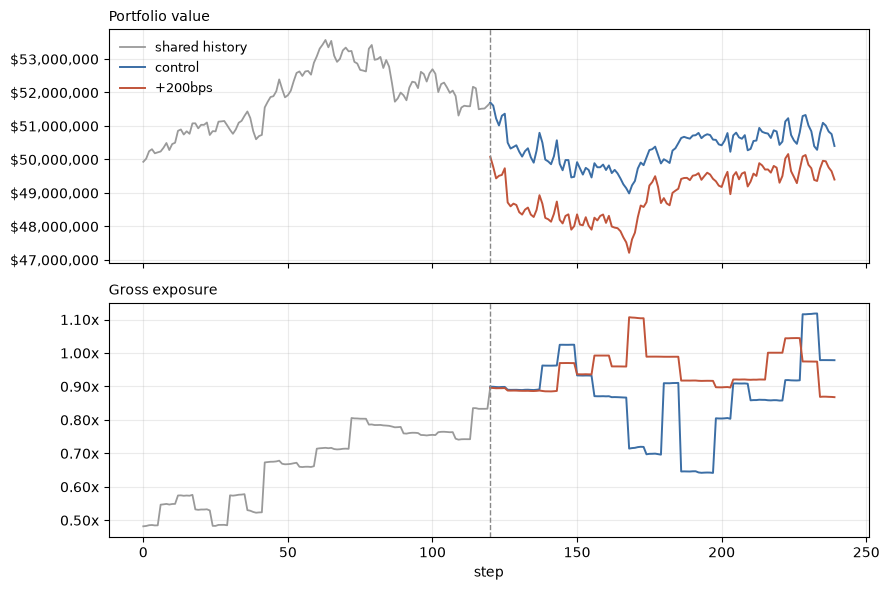

In [14]:
import matplotlib.pyplot as plt

# ASCII punctuation, which is the project's voice and which matplotlib does
# not follow by default: it renders a negative tick with U+2212.
plt.rcParams["axes.unicode_minus"] = False

fork = control.fork_step
steps = [row["step"] for row in control.trace]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, field, title, fmt in (
        (axes[0], "net_worth", "Portfolio value", "${x:,.0f}"),
        (axes[1], "exposure", "Gross exposure", "{x:.2f}x")):
    # The shared history once, in grey. Drawn twice, one arm sits exactly on
    # top of the other and the reader has to wonder which one is hidden.
    ax.plot(steps[:fork + 1], [r[field] for r in control.trace[:fork + 1]],
            color="#9a9a9a", linewidth=1.3, label="shared history")
    for world, colour, name in ((control, "#3b6ea5", "control"),
                                (shock, "#c1543a", "+200bps")):
        ax.plot(steps[fork:], [r[field] for r in world.trace[fork:]],
                color=colour, linewidth=1.4, label=name)
    ax.axvline(fork, color="#888888", linestyle="--", linewidth=1)
    ax.set_title(title, loc="left", fontsize=10)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[1].set_xlabel("step")
fig.tight_layout()
plt.show()

### What it traded

Net notional per name **after the fork**, in duration order. The table above
says where the two portfolios ended up. This says what the agent did to get
there, which is the question the experiment asks.

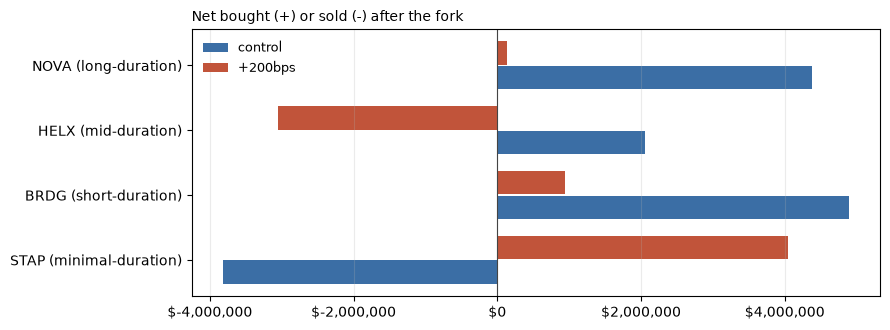

In [15]:
def net_notional(world):
    fork = world.fork_step or 0
    totals = {t: 0.0 for t in world.engine.tickers}
    for row in world.trace[fork:]:
        for fill in row["fills"]:
            totals[fill["ticker"]] += fill["quantity"] * fill["price"]
    return totals


left, right = net_notional(control), net_notional(shock)
names = [experiment._label(row) for row in experiment.BY_DURATION]
order = [row[0] for row in experiment.BY_DURATION]
y = range(len(order))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([i + 0.19 for i in y], [left[t] for t in order], height=0.36,
        color="#3b6ea5", label="control")
ax.barh([i - 0.19 for i in y], [right[t] for t in order], height=0.36,
        color="#c1543a", label="+200bps")
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_yticks(list(y), names)
ax.invert_yaxis()
ax.xaxis.set_major_formatter("${x:,.0f}")
ax.set_title("Net bought (+) or sold (-) after the fork", loc="left",
             fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## 12. What Tradefloor knew and FinRobot did not

Shown **after** the experiment, never before. The boundary means every
decision above was taken without it.

Fair value is the model's own valuation, computed from the same public
fundamentals the agent had and the discount rate it could see. So in principle
the agent could derive it. Handed it directly, the agent would be inverting
the simulator.

In [16]:
rows = []
for row in experiment.BY_DURATION:
    def valued(policy, discount):
        return tf.fair_value(eps=row[5], sector=row[1], revenue_growth=row[7],
                             book_value_per_share=row[6],
                             federal_funds_rate=policy,
                             corporate_bond_yield=discount).fair_value

    a = valued(experiment.POLICY_RATE, experiment.DISCOUNT_RATE)
    b = valued(experiment.SHOCKED_POLICY_RATE, experiment.SHOCKED_DISCOUNT_RATE)
    rows.append([experiment._label(row), f"{a:,.2f}", f"{b:,.2f}",
                 f"{b / a - 1:+.1%}"])

print("FinRobot did not receive any of this.\n")
table(rows, ["model fair value", "control", "rate shock", "delta"])

FinRobot did not receive any of this.



,control,rate shock,delta
model fair value,,,
NOVA (long-duration),110.79,104.92,-5.3%
HELX (mid-duration),88.41,84.69,-4.2%
BRDG (short-duration),69.60,67.20,-3.4%
STAP (minimal-duration),50.81,49.22,-3.1%


The valuation falls furthest for the longest-duration name, and the model does
that by construction. The tables above measure whether the agent's own
rotation matched it, without being told that rates were the thing that
changed.

What FinRobot observed: prices, recent returns, realised volatility, the top of
the book, average daily volume, its own positions and cash, the funding limit
and the buying power left under it, the published macro fields, and public
company fundamentals.

What Tradefloor knows about this simulated world: all of that, plus every
company's fair value, the nine-way decomposition of every price move, each
company's mispricing, the generator state and the macro path ahead.

One qualification on the fair-value table, because it is easy to over-read.
`tradefloor.fair_value` is public and takes only the four fundamentals
supplied above plus two macro fields the agent can see, so an agent given
full fundamentals has been given the means to reconstruct this anchor. The
adapter does not hand it over; that is a different claim from the agent being
unable to derive it, and the module docstring sets out which is which.

---

## Same starting market. Same FinRobot agent. One controlled intervention.

**Tradefloor measures what the agent actually does differently.**

Ground truth about *this* market, and about no real one. Treat it as a
controlled synthetic experiment. It predicts nothing about how real securities
would react to a real rate rise.

---

FinRobot is a project of the
[AI4Finance Foundation](https://github.com/AI4Finance-Foundation/FinRobot),
Apache-2.0. This is a Tradefloor integration for FinRobot. AI4Finance neither
maintains nor endorses it. It is no part of FinRobot's own interface.

The adapter is `tradefloor/integrations/finrobot.py`. The same experiment as a
script is `rate_shock.py`. `tests/test_finrobot.py` keeps both honest.